In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load datasets

#### Initial Exploration and Primary Key identification

In [ ]:
orders = pd.read_csv('orders.csv')
import re


orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [331]:
# category_translation = pd.read_csv('category_translation.csv')
# category_translation.head()
category_translation.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [422]:
# customers = pd.read_csv('customers.csv')
# customers.head()

customers.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [156]:
location = pd.read_csv('location.csv')
location.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [157]:
order_item = pd.read_csv('order_item.csv')
order_item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [158]:
payments = pd.read_csv('payments.csv')
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [159]:
products = pd.read_csv('products.csv')

products.head()
# products.describe()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [317]:
reviews = pd.read_csv('reviews.csv')

reviews.head()
# reviews.isna().sum()
# reviews.nunique()



,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [327]:
sellers = pd.read_csv('sellers.csv')
# sellers.head()
sellers.nunique()

seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

## Missing Value analyses

In [206]:
#Missing values in orders dataset
# orders.isna().sum()

#order_approved_at, order_delivered_carrier_date, order_delivered_customer_date have missing values. 


#replace missing order approved at with order purchase timestamp
# orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])    


# x = pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_estimated_delivery_date'])    


# plt.hist(x.dt.days, bins=30)
# x.describe()

# Null order delivered carrier date  when order delivered customer date is not null. 
# This means that the order was delivered to the customer but we do not have the information about when it was delivered to the carrier.
# We can impute the missing values based on the average delivery time for each category of products. But for now hold.

# Group by order_status and count null values in order_delivered_customer_date
# print("Null values in order_delivered_customer_date by order_status:")
# print(orders.groupby('order_status').apply(lambda x: x.isna().sum()))

# print("Null values in order table:")
# print(orders.isna().sum())

# print("Null values in reviews table:")
# print(reviews.isna().sum())

# print("Null values in sellers table:")
# print(sellers.isna().sum())

print("Null values in order_item table:")
print(order_item.isna().sum())

# Looking at the distribution, depending on objective of analyses, we can decided missing value strategy. 
# For example, if we are interested in analyzing the delivery times for different categories of products, we can impute the missing values based on the average delivery time for each category.
# If we are interested in analyzing the order approval times, we can impute the missing values based on the order purchase timestamp.
# 
# # weights = products['product_weight_g'].replace(0, np.nan).astype(float)
# metric_l_h_w = (
#     products['product_length_cm'].astype(float) * products['product_width_cm'].astype(float) * products['product_height_cm'].astype(float)
# ) / weights
# # products[products['product_length_cm'] != None].describe()

# metric_l_h_w.idxmax()
# metric_l_h_w.describe()
# metric_l_h_w[metric_l_h_w.idxmax()]
# products.loc[metric_l_h_w.idxmax(), ['product_length_cm', 'product_width_cm', 'product_height_cm', 'product_weight_g']]
# weights.iloc[metric_l_h_w.argmax()]
# products['product_length_cm'].astype(float) * products['product_width_cm'].astype(float) * products['product_height_cm'].astype(float) 


Null values in order_item table:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


# Data Cleaning and Pre-processing

1) Remove missing values

In [191]:
# Missing value treatment



#missing value in product dataset

#Missing values in products dataset 
print(products.isna().sum())
# products.count()

#Dropping records where everything but the id is missing.
# 1. Get a list of all columns except the ID
cols_to_check = products.columns.difference(['product_id'])

# 2. Drop rows where any columns in that list are NaN
products = products.dropna(subset=cols_to_check, how='any')

#Missing values product_category_name have 1463 missing values. 
#Missing values product_name_lenght, product_description_lenght, product_photos_qty have 1603 missing values. 

products[products.isna().any(axis=1)].head()    

# Only products treated. For Order and Order_list, we will impute if analyses below needs it. For now, we will hold.



product_id                    0
product_category_name         0
product_name_length           0
product_description_length    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


2) Duplicate removal

In [208]:
# orders should have unique order_id
duplicate_orders = orders[orders.duplicated(subset=['order_id'], keep=False)]
print("Duplicate order_id in orders:", len(duplicate_orders))
duplicate_orders.head()

# products should have unique product_id
duplicate_products = products[products.duplicated(subset=['product_id'], keep=False)]
print("Duplicate product_id in products:", len(duplicate_products))
duplicate_products.head()

# order_item may be unique by order_id + product_id + seller_id
duplicate_order_item = order_item[order_item.duplicated(subset=['order_id', 'product_id', 'seller_id'], keep=False)]
print("Duplicate order-item rows:", len(duplicate_order_item))
duplicate_order_item.head()

# customers may be unique by customer_id
duplicate_customers = customers[customers.duplicated(subset=['customer_id'], keep=False)]
print("Duplicate customer rows:", len(duplicate_customers))
duplicate_customers.head()

category_translation


# category_translation may be unique by product_category_name
duplicate_category_translation = category_translation[category_translation.duplicated(subset=['product_category_name'], keep=False)]
print("Duplicate category translation rows:", len(duplicate_category_translation))
duplicate_category_translation.head()

# payments may be unique by order_id
duplicate_payments= payments[payments.duplicated(subset=['order_id', 'payment_sequential'], keep=False)]
print("Duplicate payment rows:", len(duplicate_payments))
duplicate_payments.head()

# reviews may be unique by review_id
duplicate_reviews = reviews[reviews.duplicated(subset=['review_id'], keep=False)]
print("Duplicate reviews rows:", len(duplicate_reviews))
duplicate_reviews.head()

# sellers may be unique by seller_id
duplicate_sellers = sellers[sellers.duplicated(subset=['seller_id'], keep=False)]
print("Duplicate seller rows:", len(duplicate_sellers))
duplicate_sellers.head()


# Only order_item and rreviews has duplicates. We can drop duplicates based on order_id + product_id + seller_id and keep the first occurrence.
order_item = order_item.drop_duplicates(
    subset=['order_id', 'product_id', 'seller_id'],
    keep='first'
)

reviews = reviews.drop_duplicates(
    subset='review_id',
    keep='first'
)


Duplicate order_id in orders: 0
Duplicate product_id in products: 0
Duplicate order-item rows: 0
Duplicate customer rows: 0
Duplicate category translation rows: 0
Duplicate payment rows: 0
Duplicate reviews rows: 0
Duplicate seller rows: 0


3) Convert string (date) to datetime columns 

In [196]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders[date_cols] = orders[date_cols].apply(pd.to_datetime, errors='coerce')


4. Validate data types and ranges

In [197]:
def validate_data_types(df):
    for col in df.columns:
        name = [n for n, v in globals().items() if v is df][0]
        print(f"\nTable: {name}")

        if df[col].dtype == 'object':
            print(f"Unique values in {col}: {df[col].nunique()}")
        elif df[col].dtype in ['int64','float64', 'datetime64[ns]']:
            print(f"Data type of {col}: {df[col].dtype}")
            print(f'Max value in {col}: {df[col].max()}')
            print(f'Min value in {col}: {df[col].min()}')
validate_data_types(orders)
validate_data_types(category_translation)
validate_data_types(customers)
validate_data_types(location)
validate_data_types(order_item)
validate_data_types(payments)
validate_data_types(products)
validate_data_types(reviews)
validate_data_types(sellers)    


Table: orders
Unique values in order_id: 99441

Table: orders
Unique values in customer_id: 99441

Table: orders
Unique values in order_status: 8

Table: orders
Data type of order_purchase_timestamp: datetime64[ns]
Max value in order_purchase_timestamp: 2018-10-17 17:30:18
Min value in order_purchase_timestamp: 2016-09-04 21:15:19

Table: orders
Data type of order_approved_at: datetime64[ns]
Max value in order_approved_at: 2018-10-17 17:30:18
Min value in order_approved_at: 2016-09-15 12:16:38

Table: orders
Data type of order_delivered_carrier_date: datetime64[ns]
Max value in order_delivered_carrier_date: 2018-09-11 19:48:28
Min value in order_delivered_carrier_date: 2016-10-08 10:34:01

Table: orders
Data type of order_delivered_customer_date: datetime64[ns]
Max value in order_delivered_customer_date: 2018-10-17 13:22:46
Min value in order_delivered_customer_date: 2016-10-11 13:46:32

Table: orders
Data type of order_estimated_delivery_date: datetime64[ns]
Max value in order_estima

5) Standardize Column names

In [198]:
# Standardize column names

# Rename misspelled column

products = products.rename(columns={ 
     'product_name_lenght': 'product_name_length',
     'product_description_lenght': 'product_description_length'
 })

# Merge datasets

In [446]:
##### Goal to create one data set
### Start with orders and customers


order_customer= pd.merge(orders, customers, on='customer_id', how='left')


## Add order_item to order_customer
y = pd.merge(order_customer, order_item, on='order_id', how='left') 

y.describe(include='all')


# order_item.query('order_id == "ca3625898fbd48669d50701aba51cd5f"') #Sum order item price and freight value| Decided aganst as we want to keep product level details for analyses.

### Add products to order_customer_item

z = pd.merge(y, products[[ 'product_id', 'product_category_name' ]], on='product_id', how='left')

## Add payments to order_customer_item_product
# From payments table:
# 1) Sum payment_value for each order_id
# 2) Keep only the first payment_type (payment_sequential == 1) for each order

# Sum payment_value per order_id
payment_sums = payments.groupby('order_id')['payment_value'].sum().reset_index()

## Get the first payment_type (payment_sequential == 1) per order_id
first_payment_types = payments[payments['payment_sequential'] == 1][['order_id', 'payment_type']]

## Merge to create payments_agg
payments_agg = payment_sums.merge(first_payment_types, on='order_id', how='left')

payments_agg.rename(columns={'payment_type': 'first_payment_type'}, inplace=True)

m = pd.merge(z, payments_agg, on='order_id', how='left')

## Merge reviews to order_customer_item_product_payment

reviews_aggregate = reviews.groupby('order_id').agg({
    'review_score': 'mean',
    'review_comment_message': lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else None
}).reset_index()

n = pd.merge(m, reviews_aggregate, on='order_id', how='left')

## Merge sellers to order_customer_item_product_payment_reviews

ocippr = pd.merge(n, sellers[['seller_id', 'seller_state', 'seller_city']], on='seller_id', how='left')

## Merge category_translation to ocippr to get product category name in English
ocippr_category = pd.merge(ocippr, category_translation, on='product_category_name', how='left')
print(ocippr.info())
print(ocippr_category.describe())
print(ocippr_category.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103200 entries, 0 to 103199
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103200 non-null  object        
 1   customer_id                    103200 non-null  object        
 2   order_status                   103200 non-null  object        
 3   order_purchase_timestamp       103200 non-null  datetime64[ns]
 4   order_approved_at              103200 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101398 non-null  datetime64[ns]
 6   order_delivered_customer_date  100195 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103200 non-null  datetime64[ns]
 8   customer_unique_id             103200 non-null  object        
 9   customer_zip_code_prefix       103200 non-null  int64         
 10  customer_city                  103200 non-null  object        
 11  

In [477]:
final = ocippr_category.copy()

# final.isna().sum()
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103200 entries, 0 to 103199
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103200 non-null  object        
 1   customer_id                    103200 non-null  object        
 2   order_status                   103200 non-null  object        
 3   order_purchase_timestamp       103200 non-null  datetime64[ns]
 4   order_approved_at              103200 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101398 non-null  datetime64[ns]
 6   order_delivered_customer_date  100195 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103200 non-null  datetime64[ns]
 8   customer_unique_id             103200 non-null  object        
 9   customer_zip_code_prefix       103200 non-null  int64         
 10  customer_city                  103200 non-null  object        
 11  

# Feature Engineering

In [ ]:
# Number of items per order in the final dataset
# final.loc[:, 'items'] = round((
#     final['payment_value'] /
#     (final['freight_value'] + final['price'])
# ),2)

# Total Value = payment_value

# Delivery Time
# final = final.copy()

# final.loc[:, 'delivery_time_days'] = (final['order_delivered_customer_date'] - final['order_purchase_timestamp']).dt.days

# final.delivery_time_days.describe()

# Customer purchase frequency and Average order value per customer 

# result = final.drop_duplicates(subset='order_id', keep='first')

customer_metrics = (
result.groupby('customer_unique_id')
.agg(
orders=('order_id','nunique'),
avg_order_value=('payment_value','mean'),
first_order=('order_approved_at','min'),
last_order=('order_approved_at','max'),
customer_city=('customer_city','first'),
customer_state=('customer_state','first')
)
)

customer_metrics['customer_lifetime_months'] = (
(
customer_metrics['last_order']
- customer_metrics['first_order']
).dt.days / 30
).clip(lower=1)

customer_metrics['orders_per_month'] = (
    customer_metrics['orders'] /
    customer_metrics['customer_lifetime_months']
)

# Customer Lifetime Value
customer_metrics['Total_Value'] = customer_metrics['avg_order_value']*customer_metrics['orders']
# print(a.sort_values())



 

customer_unique_id
968fac81e2c44fb6c1e3ac2a45e6a102       0.0
4fa4365000c7090fcb8cad5713c6d3db       0.0
317cfc692e3f86c45c95697c61c853a6       9.6
bd06ce0e06ad77a7f681f1a4960a3cc6      10.1
b33336f46234b24a613ad9064d13106d      10.9
                                     ...  
763c8b1c9c68a0229c42c9fc6f662b93    7274.9
da122df9eeddfedc1dc1f5349a1a690c    7571.6
46450c74a0d8c5ca9395da1daac6c120    9553.0
0a0a92112bd4c708ca5fde585afaa872   13664.1
830d5b7aaa3b6f1e9ad63703bec97d23       NaN
Length: 96096, dtype: float64


# Exploratory Data Analysis (EDA)

In [ ]:
# Customer Analysis

# 1. New vs Returning Customers: Analyze the proportion of new customers (first-time buyers) versus returning customers. 
# This can help identify customer loyalty and retention rates.

# customer_metrics['customer_segment'] = customer_metrics.apply(
#     lambda row: 
#         'new' if row['orders'] == 1 else
#         'active' if (pd.Timestamp('today') - row['last_order']).days <= 90
#         else 'churned'
#     ,
#     axis=1
# )

# pd.set_option('display.float_format', '{:.1f}'.format)

# customer_metrics['total_revenue'] = customer_metrics['avg_order_value'] * customer_metrics['orders']

# customer_metrics.groupby('customer_segment')['total_revenue'].agg(['mean', 'median', 'count', 'sum'])

# <1% of customers are not first time buyers. This means that majority of the customers are not returning customers. 
# This is a red flag for the business as it indicates that the business is not able to retain customers and build loyalty. 
# The business needs to focus on improving customer retention and loyalty to increase revenue and profitability.

# High-value vs low-value customers 
#75% percentile is 177.2; 25th percentile is 62.5. The IQR*1.5 + 177.2 = 350 let's assume above that is high value and below that is low value.

customer_metrics['customer_value_segment'] = customer_metrics['avg_order_value'].apply(
    lambda x: 'high-value' if x > 350 else 'low-value'
)   

customer_metrics.groupby('customer_value_segment')['Total_Value'].sum().pipe(lambda x: x / x.sum() * 100)

customer_metrics.groupby('customer_value_segment')['Total_Value'].count().pipe(lambda x: x / x.sum() * 100)
# High value customers account for 33.6% of total value whereas they are just 7.9% of the customer base!

# Geographic distribution of customers 
customer_metrics.groupby('customer_state')['Total_Value'].sum().sort_values(ascending=False).head(30).pipe(lambda x: x / x.sum() * 100)

#top 3 states SP, RJ, MG account for 60%+ of the revenue.
# customer_metrics.groupby('customer_city')['Total_Value'].sum().sort_values(ascending=False).head(30).pipe(lambda x: x / x.sum() * 100)
#top 2 cities sao paulo and rio de janeiro account for 47% of the revenue.

customer_state
SP   37.5
RJ   13.4
MG   11.7
RS    5.6
PR    5.1
SC    3.9
BA    3.9
DF    2.2
GO    2.2
ES    2.0
PE    2.0
CE    1.7
PA    1.4
MT    1.2
MA    1.0
PB    0.9
MS    0.9
PI    0.7
RN    0.6
AL    0.6
SE    0.5
TO    0.4
RO    0.4
AM    0.2
AC    0.1
AP    0.1
RR    0.1
Name: Total_Value, dtype: float64

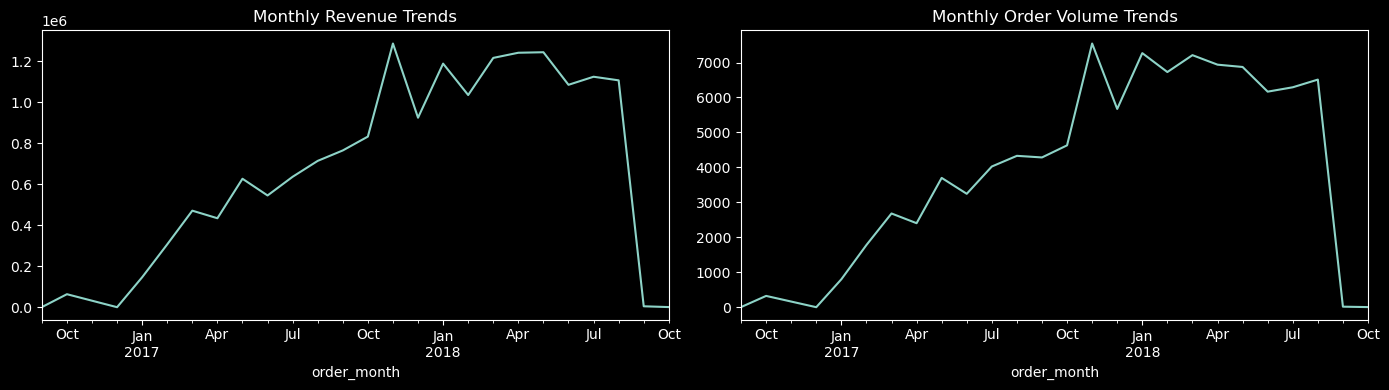

In [633]:
# Revenue and Order Analysis
# 	•	Monthly revenue trends 
# 	•	Order volume trends 
# 	•	Peak sales periods 

# Generate monthly revenue trends
final['order_month'] = final['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = final.groupby('order_month')['payment_value'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_revenue.plot(ax=axes[0], kind='line', title='Monthly Revenue Trends')

monthly_orders = final.groupby('order_month')['order_id'].nunique()

# Generate monthly order volume trends
monthly_orders.plot(ax=axes[1], kind='line', title='Monthly Order Volume Trends')

plt.tight_layout()
plt.show()

#Oct 2018 seems like peak sales period. We can further analyze the sales by category to see if there are any specific categories that are driving the sales in October.



<Figure size 1600x600 with 0 Axes>

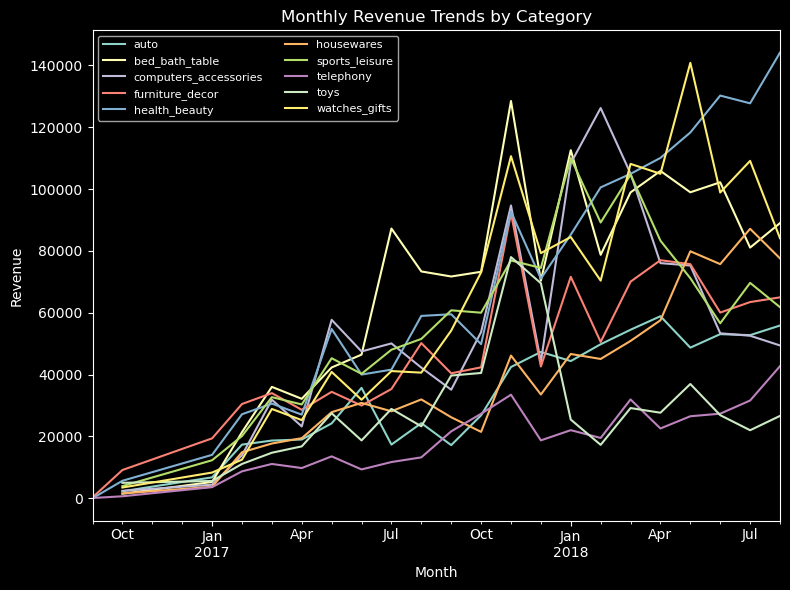

In [653]:
plt.figure(figsize=(16, 6))
top_10_categories = final['product_category_name_english'].value_counts().head(10).index
monthly_revenue_cat = final[final['product_category_name_english'].isin(top_10_categories)].groupby(['order_month', 'product_category_name_english'])['payment_value'].sum()
monthly_revenue_cat = monthly_revenue_cat.unstack()

fig, ax = plt.subplots(figsize=(8, 6))

monthly_revenue_cat.plot(ax = ax)
ax.legend(fontsize=8, ncol=2)
plt.title('Monthly Revenue Trends by Category')
plt.ylabel('Revenue')
plt.xlabel('Month')
# ax.legend(fontsize=7)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

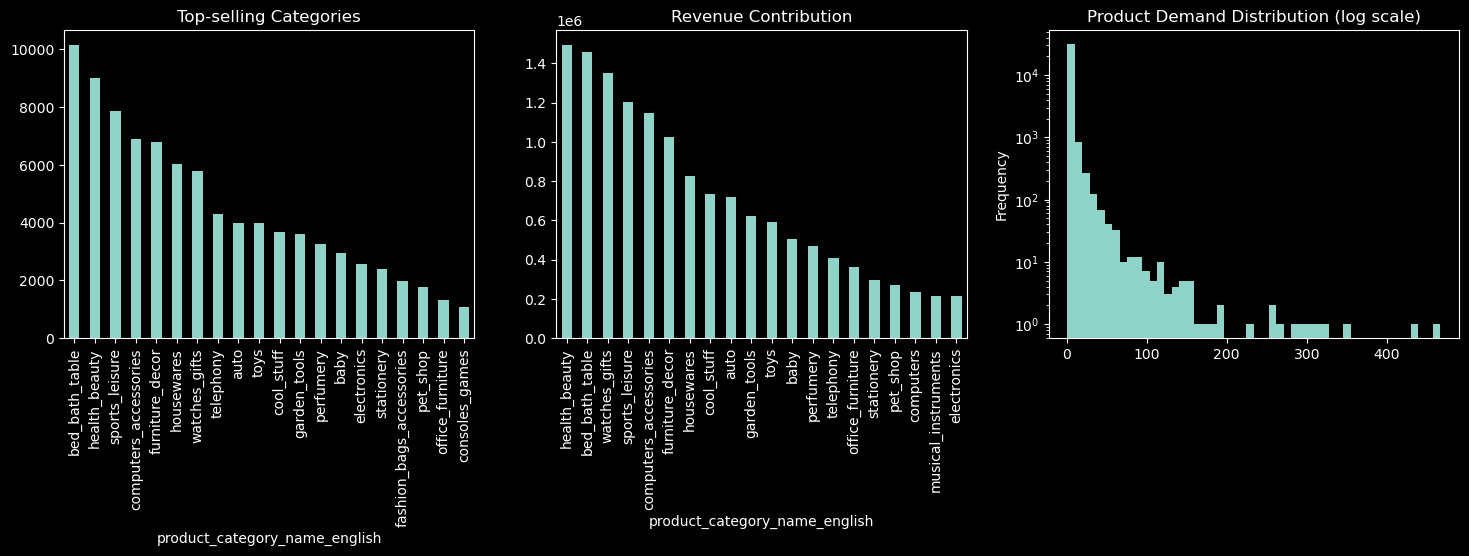

<Figure size 640x480 with 0 Axes>

In [559]:
# Product Analysis
# 	•	Top-selling product categories 
# 	•	Revenue contribution by category 
# 	•	Product demand distribution 

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Top categories (count)
final['product_category_name_english'].value_counts().head(20).plot(
    kind='bar', ax=axes[0], title='Top-selling Categories'
)

# 2. Revenue contribution
final.groupby('product_category_name_english')['payment_value'].sum()\
    .sort_values(ascending=False).head(20).plot(
        kind='bar', ax=axes[1], title='Revenue Contribution'
)

# 3. Demand distribution (counts sorted)
final['product_id'].value_counts().plot(
    kind='hist',
    bins=50,
    logy=True,
    ax=axes[2],
    title='Product Demand Distribution (log scale)'
)
plt.show()

plt.tight_layout()
plt.show()

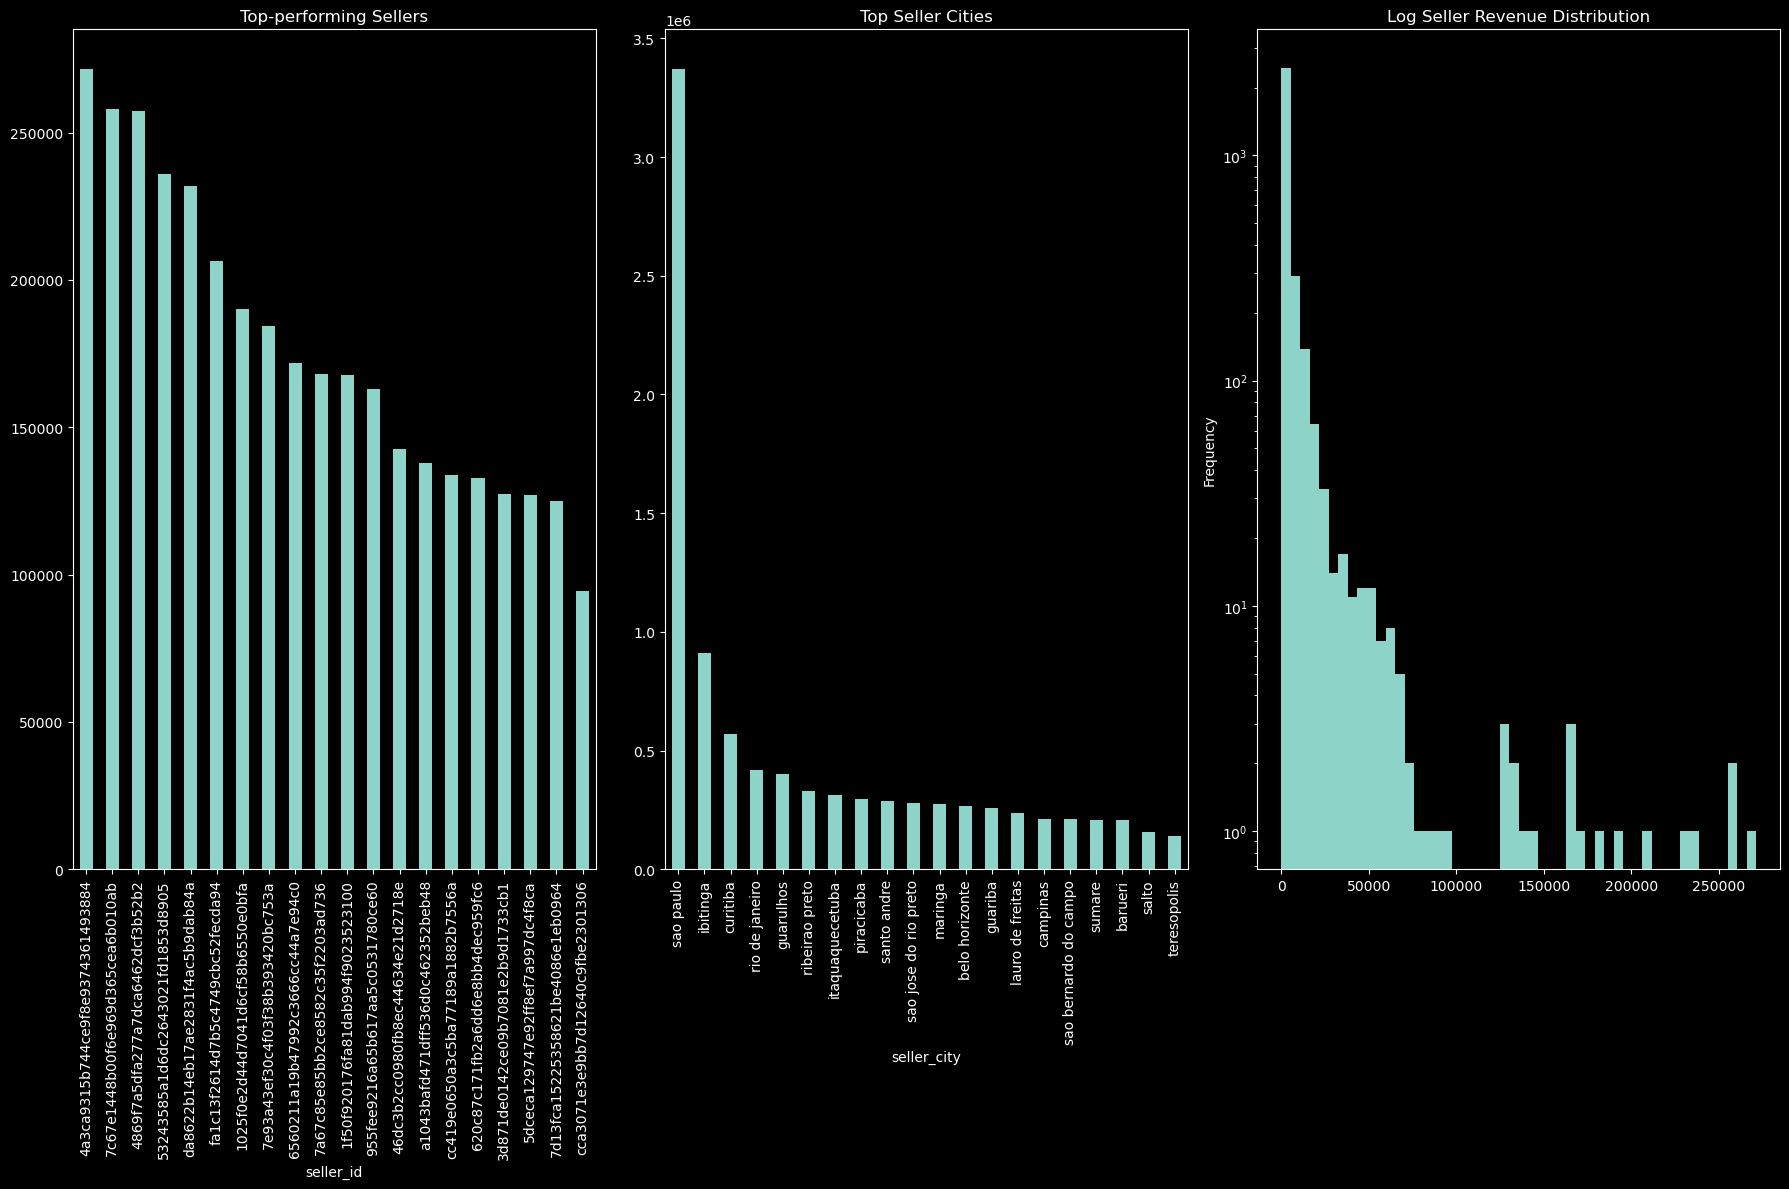

In [568]:
# Seller Analysis
# 	•	Top-performing sellers 
# 	•	Seller contribution to revenue 
# 	•	Seller distribution 

seller_sales = final.groupby('seller_id')['payment_value'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 12))

# 1. Top sellers
seller_sales.sort_values(ascending=False).head(20).plot(
    kind='bar', ax=axes[0], title='Top-performing Sellers'
)

# 2. Top seller cities (fixing your earlier logic)
final.groupby('seller_city')['payment_value'].sum().sort_values(ascending=False).head(20).plot(
    kind='bar', ax=axes[1], title='Top Seller Cities'
)

# 3. Seller distribution (KEY PLOT)
seller_sales.plot(
    kind='hist', bins=50, ax=axes[2],
    logy=True,
    title='Log Seller Revenue Distribution'
)

plt.tight_layout()
plt.show()

In [ ]:
seller_sales = final.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False)

top_20_pct = int(0.2 * len(seller_sales))
share = seller_sales.head(top_20_pct).sum() / seller_sales.sum()

print(f"Top 20% sellers contribute {share:.2%} of total revenue")

#Top 20% of sellers contribute 80% of the revenue. 
# This indicates a highly skewed distribution of revenue among sellers, with a small percentage of sellers generating the majority of the revenue. 
# This is a common pattern in marketplaces and suggests that the business may want to focus on supporting
# and retaining these top-performing sellers while also finding ways to help lower-performing sellers improve their sales.

#Top 10% of sellers contribute 66.2% of the revenue.

Top 20% sellers contribute 82.07% of total revenue


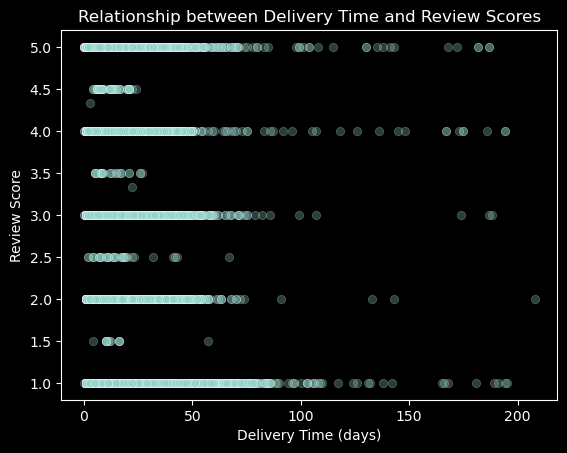

np.float64(-0.31646471105117835)

In [593]:
# Review and Satisfaction Analysis
# 	•	Distribution of review scores 
# 	•	Relationship between delivery time and ratings 
# 	•	Identification of dissatisfaction patterns 

# final.review_score.value_counts().sort_index().plot(
#     kind='bar', title='Distribution of Review Scores'
# )

final['delivery_time_days'] = (final['order_delivered_customer_date'] - final['order_purchase_timestamp']).dt.days
sns.scatterplot(
    data=final,
    x='delivery_time_days',
    y='review_score',
    alpha=0.3
)
plt.title('Relationship between Delivery Time and Review Scores')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Review Score')
plt.show()

df = final[['delivery_time_days', 'review_score']].dropna()
df['delivery_time_days'].corr(df['review_score'])

# The correlation between delivery time and review score is -0.31, which indicates a moderate negative relationship. 
# This suggests that longer delivery times are moderately associated with lower review scores, but the relationship is not strong. 
# Other factors may also be influencing review scores, and delivery time alone does not fully explain customer satisfaction.



In [ ]:
final['is_dissatisfied'] = final['review_score'] <= 2
seller_dissatisfaction = final.groupby('seller_id')['is_dissatisfied'].mean()

# seller_dissatisfaction.sort_values(ascending=False).head(10)

<Axes: xlabel='order_month'>

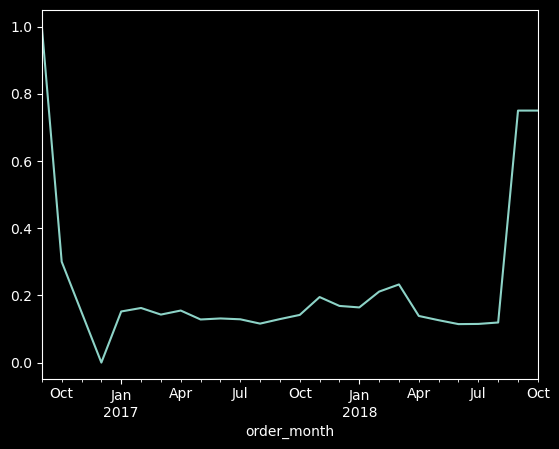

In [595]:
final['order_month'] = final['order_purchase_timestamp'].dt.to_period('M')

final.groupby('order_month')['is_dissatisfied'].mean().plot()

/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_30614/2442747903.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final.groupby('delivery_bucket')['review_score'].mean().plot(kind='bar')


<Axes: xlabel='delivery_bucket'>

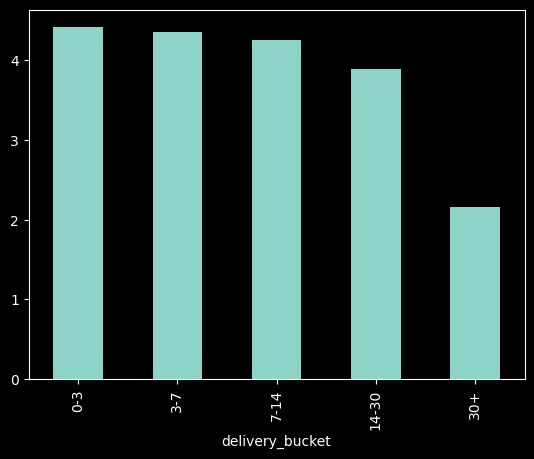

In [597]:
final['delivery_bucket'] = pd.cut(
    final['delivery_time_days'],
    bins=[0, 3, 7, 14, 30, 100],
    labels=['0-3', '3-7', '7-14', '14-30', '30+']
)

final.groupby('delivery_bucket')['review_score'].mean().plot(kind='bar')

In [599]:
final.groupby(['delivery_bucket', 'is_late'])['is_dissatisfied'].mean().unstack()

/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_30614/2950463800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final.groupby(['delivery_bucket', 'is_late'])['is_dissatisfied'].mean().unstack()


is_late,False,True
delivery_bucket,,
0-3,0.1,0.1
3-7,0.1,0.1
7-14,0.1,0.3
14-30,0.1,0.4
30+,0.2,0.7


/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_30614/2027387074.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = final[final['product_category_name_english'].isin(top_20_categories)].pivot_table(


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, '0-3'),
  Text(0, 1.5, '3-7'),
  Text(0, 2.5, '7-14'),
  Text(0, 3.5, '14-30'),
  Text(0, 4.5, '30+')])

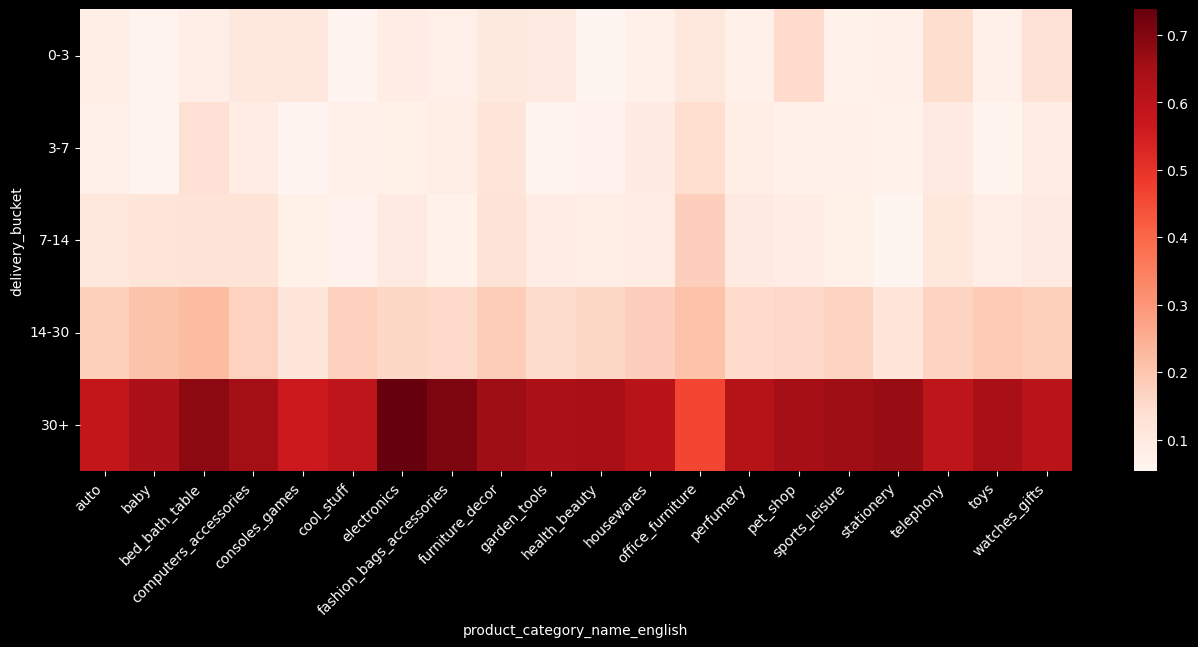

In [631]:
top_25_categories = final['product_category_name_english'].value_counts().head(25).index

pivot = final[final['product_category_name_english'].isin(top_20_categories)].pivot_table(
    index='delivery_bucket',
    columns='product_category_name_english',
    values='is_dissatisfied',
    aggfunc='mean'
)
plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap='Reds')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

In [607]:
# Adding counts to previous analyses
counts = final.groupby(['delivery_bucket', 'is_late']).size().unstack()
rate = final.groupby(['delivery_bucket', 'is_late'])['is_dissatisfied'].mean().unstack()
percent = counts / counts.values.sum()
summary = final.groupby(['delivery_bucket', 'is_late']).agg(
    total=('order_id', 'count'),
    dissatisfied=('is_dissatisfied', 'sum'),
    rate=('is_dissatisfied', 'mean')
)

summary['pct_of_total'] = summary['total'] / summary['total'].sum()

print(summary)

                         total  dissatisfied  rate  pct_of_total
delivery_bucket is_late                                         
0-3             False     8988           750   0.1           0.1
                True        56             3   0.1           0.0
3-7             False    25973          2260   0.1           0.3
                True       242            27   0.1           0.0
7-14            False    37229          3608   0.1           0.4
                True       560           155   0.3           0.0
14-30           False    19317          2477   0.1           0.2
                True      3619          1557   0.4           0.0
30+             False      679           168   0.2           0.0
                True      3453          2468   0.7           0.0


/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_30614/3997362919.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = final.groupby(['delivery_bucket', 'is_late']).size().unstack()
/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_30614/3997362919.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = final.groupby(['delivery_bucket', 'is_late'])['is_dissatisfied'].mean().unstack()
/var/folders/r2/t2lb1vw12x16gf57gwdc6qth0000gn/T/ipykernel_30614/3997362919.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas.

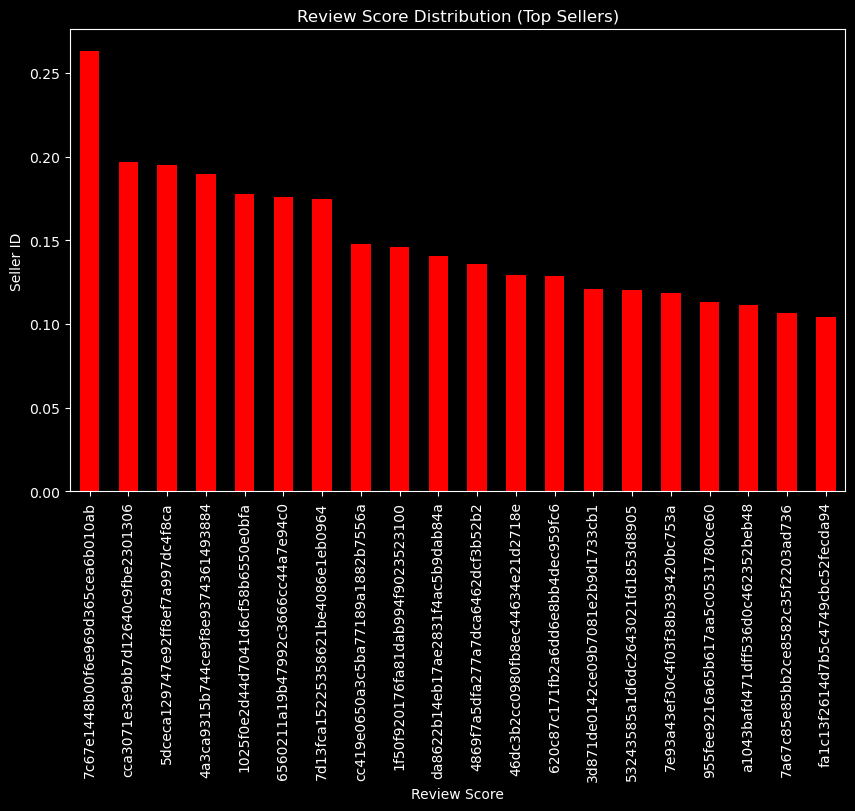

In [619]:
top_sellers = final.groupby('seller_id')['payment_value'].sum()\
    .sort_values(ascending=False).head(20).index
top_data = final[final['seller_id'].isin(top_sellers)]
review_dist = pd.crosstab(
    top_data['seller_id'],
    top_data['is_dissatisfied'],
    normalize='index'   # percentage per seller
)

review_dist[True].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,6),
    color='red'
)

# plt.figure(figsize=(10,6))
# sns.heatmap(review_dist, cmap='coolwarm_r', annot=True, fmt='.2f')
plt.title('Review Score Distribution (Top Sellers)')
plt.xlabel('Review Score')
plt.ylabel('Seller ID')
plt.show()

# Random charts/Heatmaps that might help in EDA

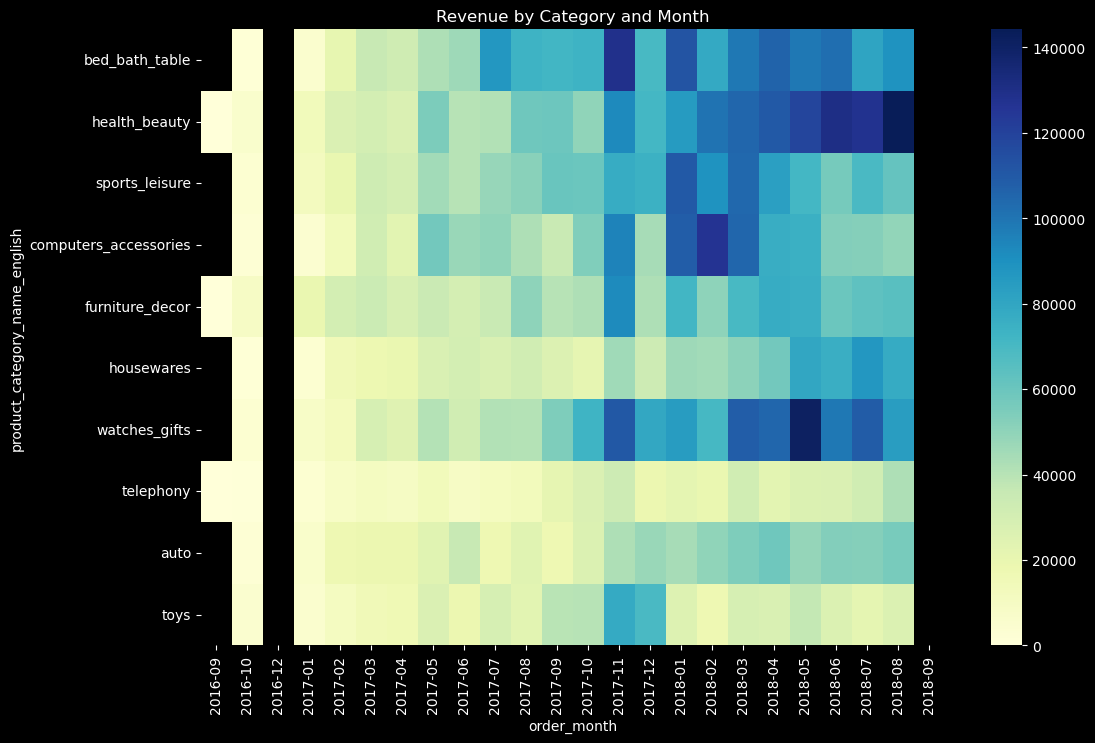

In [580]:
pivot = final.pivot_table(
    index='product_category_name_english',
    columns='order_month',
    values='payment_value',
    aggfunc='sum'
)
top_categories = final['product_category_name_english'].value_counts().head(10).index
pivot = pivot.loc[top_categories]
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Revenue by Category and Month')
plt.show()

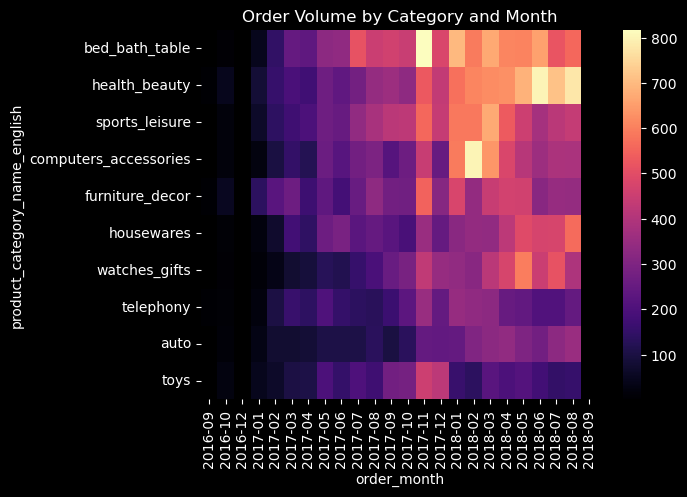

In [ ]:
#Order cateogry and order volume by month

pivot = final.pivot_table(
    index='product_category_name_english',
    columns='order_month',
    values='order_id',
    aggfunc='nunique'
)
top_categories = final['product_category_name_english'].value_counts().head(10).index
pivot = pivot.loc[top_categories]
sns.heatmap(pivot, cmap='magma')
plt.title('Order Volume by Category and Month')
plt.show()

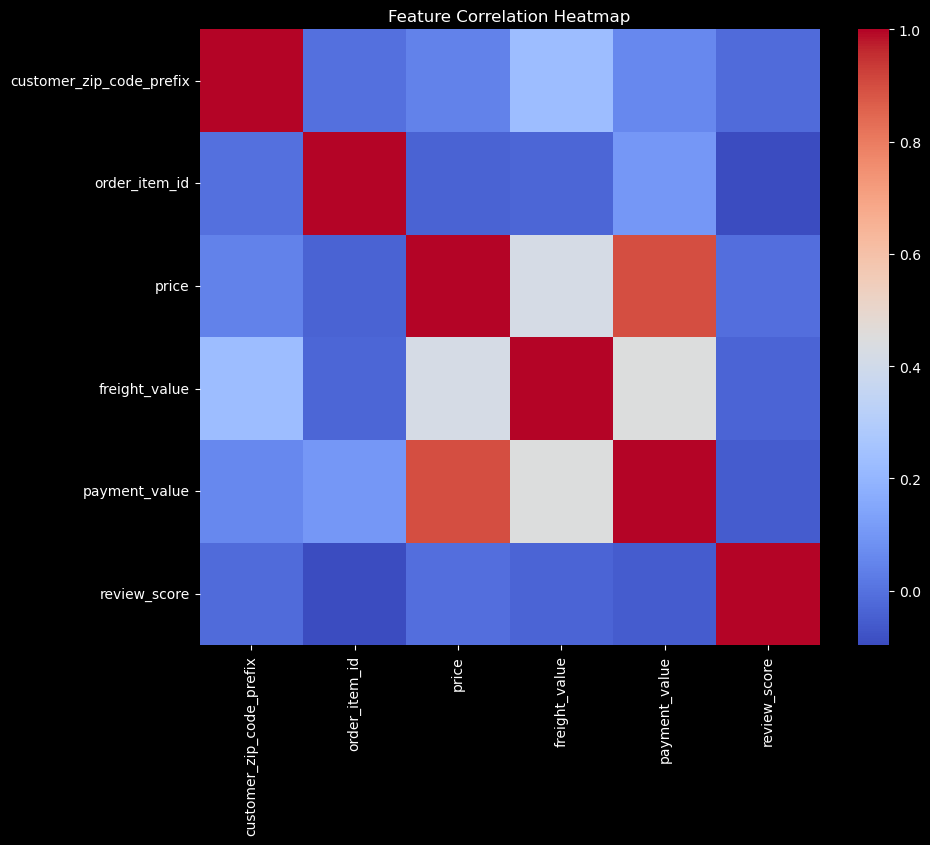

In [ ]:
#Correlation heatmap for numeric features in the final dataset

corr = final.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()